# **DECISION TREE**

## **LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sn
from matplotlib import pyplot as plt
from scipy.stats import shapiro
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report

sn.set_style("whitegrid")

## **DATA**

This dataset is the Pima Indians Diabetes Dataset, commonly used for binary classification tasks in machine learning. Dataset contains following data:
* pregnancies – number of times pregnant
* glucose – plasma glucose concentration
* pressure – diastolic blood pressure (mm Hg)
* skin – skin fold thickness (mm)
* insulin – 2-hour serum insulin (mu U/ml)
* bmi – body mass index
* pedigre – diabetes pedigree function (genetic likelihood)
* age – age in years
* class - indicator if it has or doesn't have diabetes

In [2]:
# Pima Indians Diabetes (pima-indians-diabetes.csv)
data_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
data_headers = ['pregnancies', 'glucose', 'pressure', 'skin', 'insulin', 'bmi', 'pedigre', 'age', 'class']

data_frame = pd.read_csv(data_url, names = data_headers)

### **EXPLORING**

In [3]:
print("Dataset size: ", len(data_frame))
print("Dataset dimensions: ", data_frame.shape)

# Preview dataset
data_frame.head()
data_frame.tail() # all rows are numeric

Dataset size:  768
Dataset dimensions:  (768, 9)


,pregnancies,glucose,pressure,skin,insulin,bmi,pedigre,age,class
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [4]:
data_frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pregnancies  768 non-null    int64  
 1   glucose      768 non-null    int64  
 2   pressure     768 non-null    int64  
 3   skin         768 non-null    int64  
 4   insulin      768 non-null    int64  
 5   bmi          768 non-null    float64
 6   pedigre      768 non-null    float64
 7   age          768 non-null    int64  
 8   class        768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
data_frame.nunique()

pregnancies     17
glucose        136
pressure        47
skin            51
insulin        186
bmi            248
pedigre        517
age             52
class            2
dtype: int64

In [6]:
data_frame['class'].isin([0, 1]).all() # binary variable

np.True_

Dataset's *class* variable is a **binary variable**, goal of the model is to predict it based on other feature variables.

### **CLEANING**

In [7]:
# replacing missing values with NaN
data_frame[['glucose', 'pressure', 'skin', 'insulin', 'bmi']] = data_frame[['glucose', 'pressure', 'skin', 'insulin', 'bmi']].replace(0, np.nan)
data_frame.head()

,pregnancies,glucose,pressure,skin,insulin,bmi,pedigre,age,class
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [8]:
pd.DataFrame({
    'existing': data_frame.notnull().sum(),
    'missing': data_frame.isnull().sum()
})

,existing,missing
pregnancies,768,0
glucose,763,5
pressure,733,35
skin,541,227
insulin,394,374
bmi,757,11
pedigre,768,0
age,768,0
class,768,0


*Skin* and *insulin* has lots of missing data.

### **IMPUTING**

In [9]:
columns_with_missing_values = ['glucose', 'pressure', 'skin', 'insulin', 'bmi']

data_frame_with_missing_values = data_frame.dropna()

for column in columns_with_missing_values:
    print(f"Handling missing values for column: {column}")

    # testing for normal distribution
    # H0: data is normally distributed (p > 0.05)
    # H1: data is not normally distributed (p < 0.05)

    stat, p = shapiro(data_frame_with_missing_values[column])

    if p > 0.05:
        # replace missing data with mean value
        print(f"For column {column}: (W) = {stat}, p-value: {p} - replacing with mean")
        data_frame[column] = data_frame[column].fillna(data_frame[column].mean())
    else:
        # replace missing data with median value
        print(f"For column {column}: (W) = {stat}, p-value: {p} - replacing with median")
        data_frame[column] = data_frame[column].fillna(data_frame[column].median())

Handling missing values for column: glucose
For column glucose: (W) = 0.9642306956085971, p-value: 3.4419837597709915e-08 - replacing with median
Handling missing values for column: pressure
For column pressure: (W) = 0.989944082615475, p-value: 0.008711922485350096 - replacing with median
Handling missing values for column: skin
For column skin: (W) = 0.9875800258677621, p-value: 0.001991033072936546 - replacing with median
Handling missing values for column: insulin
For column insulin: (W) = 0.8040082005482936, p-value: 1.9034742632890465e-21 - replacing with median
Handling missing values for column: bmi
For column bmi: (W) = 0.9738408670856034, p-value: 1.6567937168597838e-06 - replacing with median


In [10]:
data_frame.head()

,pregnancies,glucose,pressure,skin,insulin,bmi,pedigre,age,class
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


### **SPLITTING**

In [11]:
y = data_frame['class']
x = data_frame.drop('class', axis = 1) # axis = 1 - drop column

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0, stratify = y)
# random_state = 0 to always get same split
# stratify y keeps same class ratio in train/test

Target column is *class*, 0 means doesn't have, while 1 means it has diabetes

### **VISUALIZATION**

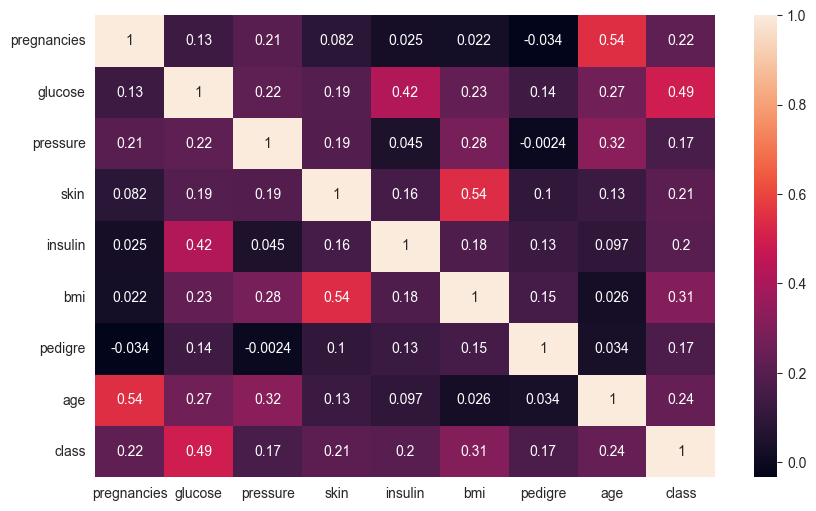

In [12]:
plt.figure(figsize=(10,6))
sn.heatmap(data_frame.corr(), annot=True)
plt.show()

*Glucose* has bit higher correlation with the *class* - moderate positive relationship.

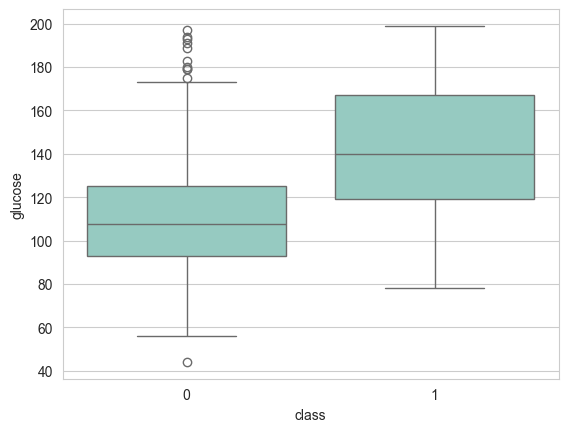

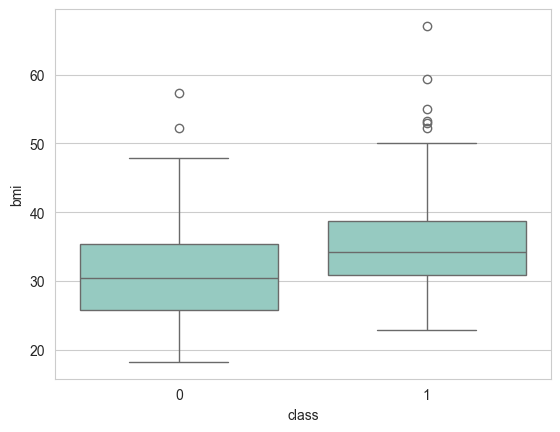

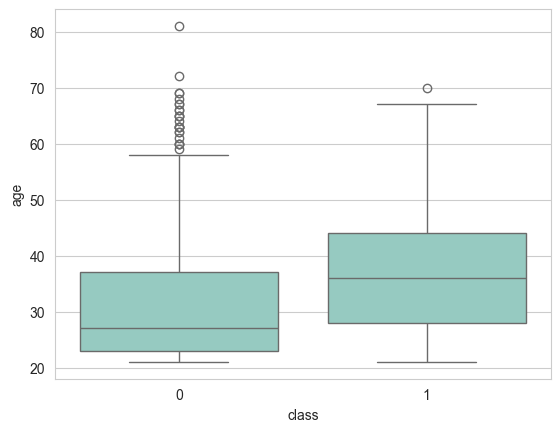

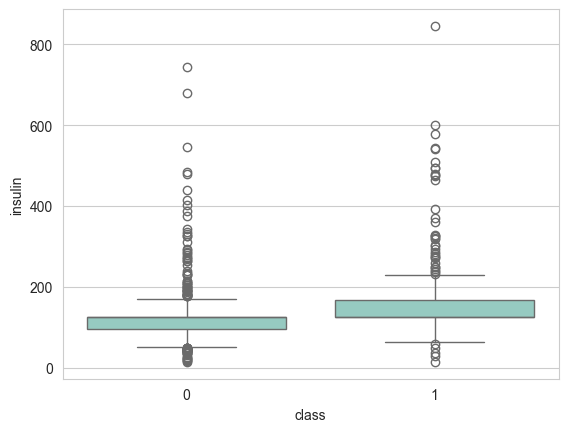

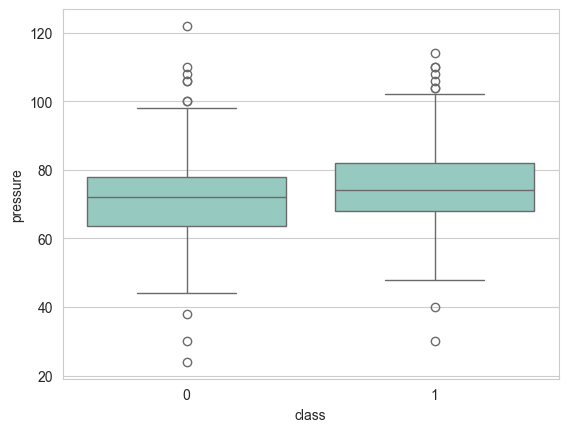

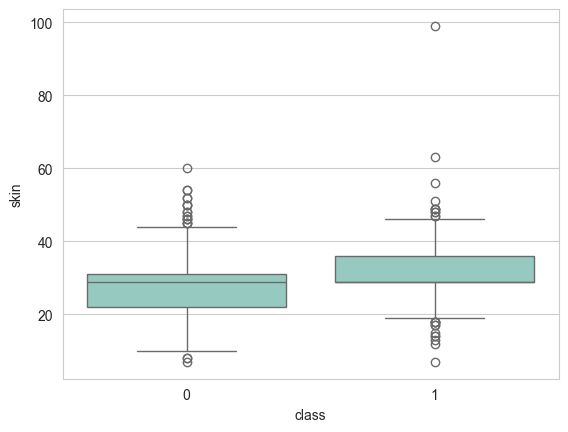

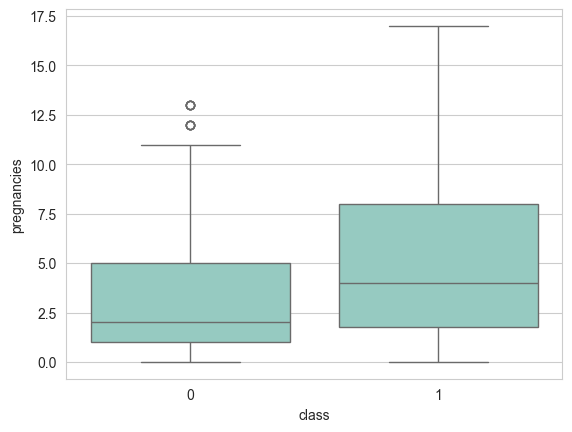

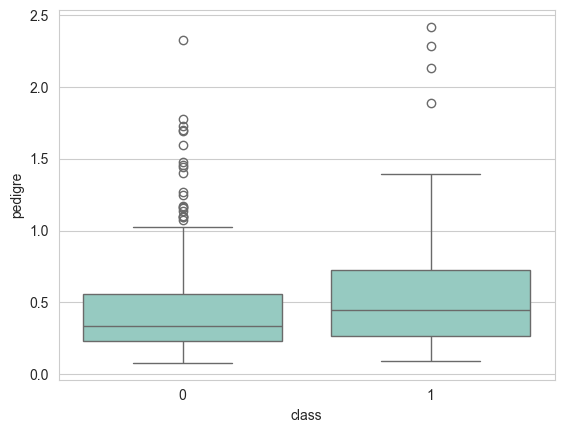

In [13]:
sn.boxplot(x="class", y="glucose", data=data_frame)
plt.show()
# Strong separation, people with high glucose tend to have diabetes

sn.boxplot(x="class", y="bmi", data=data_frame)
plt.show()
sn.boxplot(x="class", y="age", data=data_frame)
plt.show()
sn.boxplot(x="class", y="insulin", data=data_frame)
plt.show()
# Possibly weak feature, probably lots of missing values

sn.boxplot(x="class", y="pressure", data=data_frame)
plt.show()
# Possibly weak feature, medians are almost same

sn.boxplot(x="class", y="skin", data=data_frame)
plt.show()
# Possibly weak feature, probably lots of missing values

sn.boxplot(x="class", y="pregnancies", data=data_frame)
plt.show()
sn.boxplot(x="class", y="pedigre", data=data_frame)
plt.show()

Possible weak features are *insulin*, *pressure*, *skin* and *pedigre*.

## **MODEL**

### **FIRST MODEL** - DEFAULT PARAMS

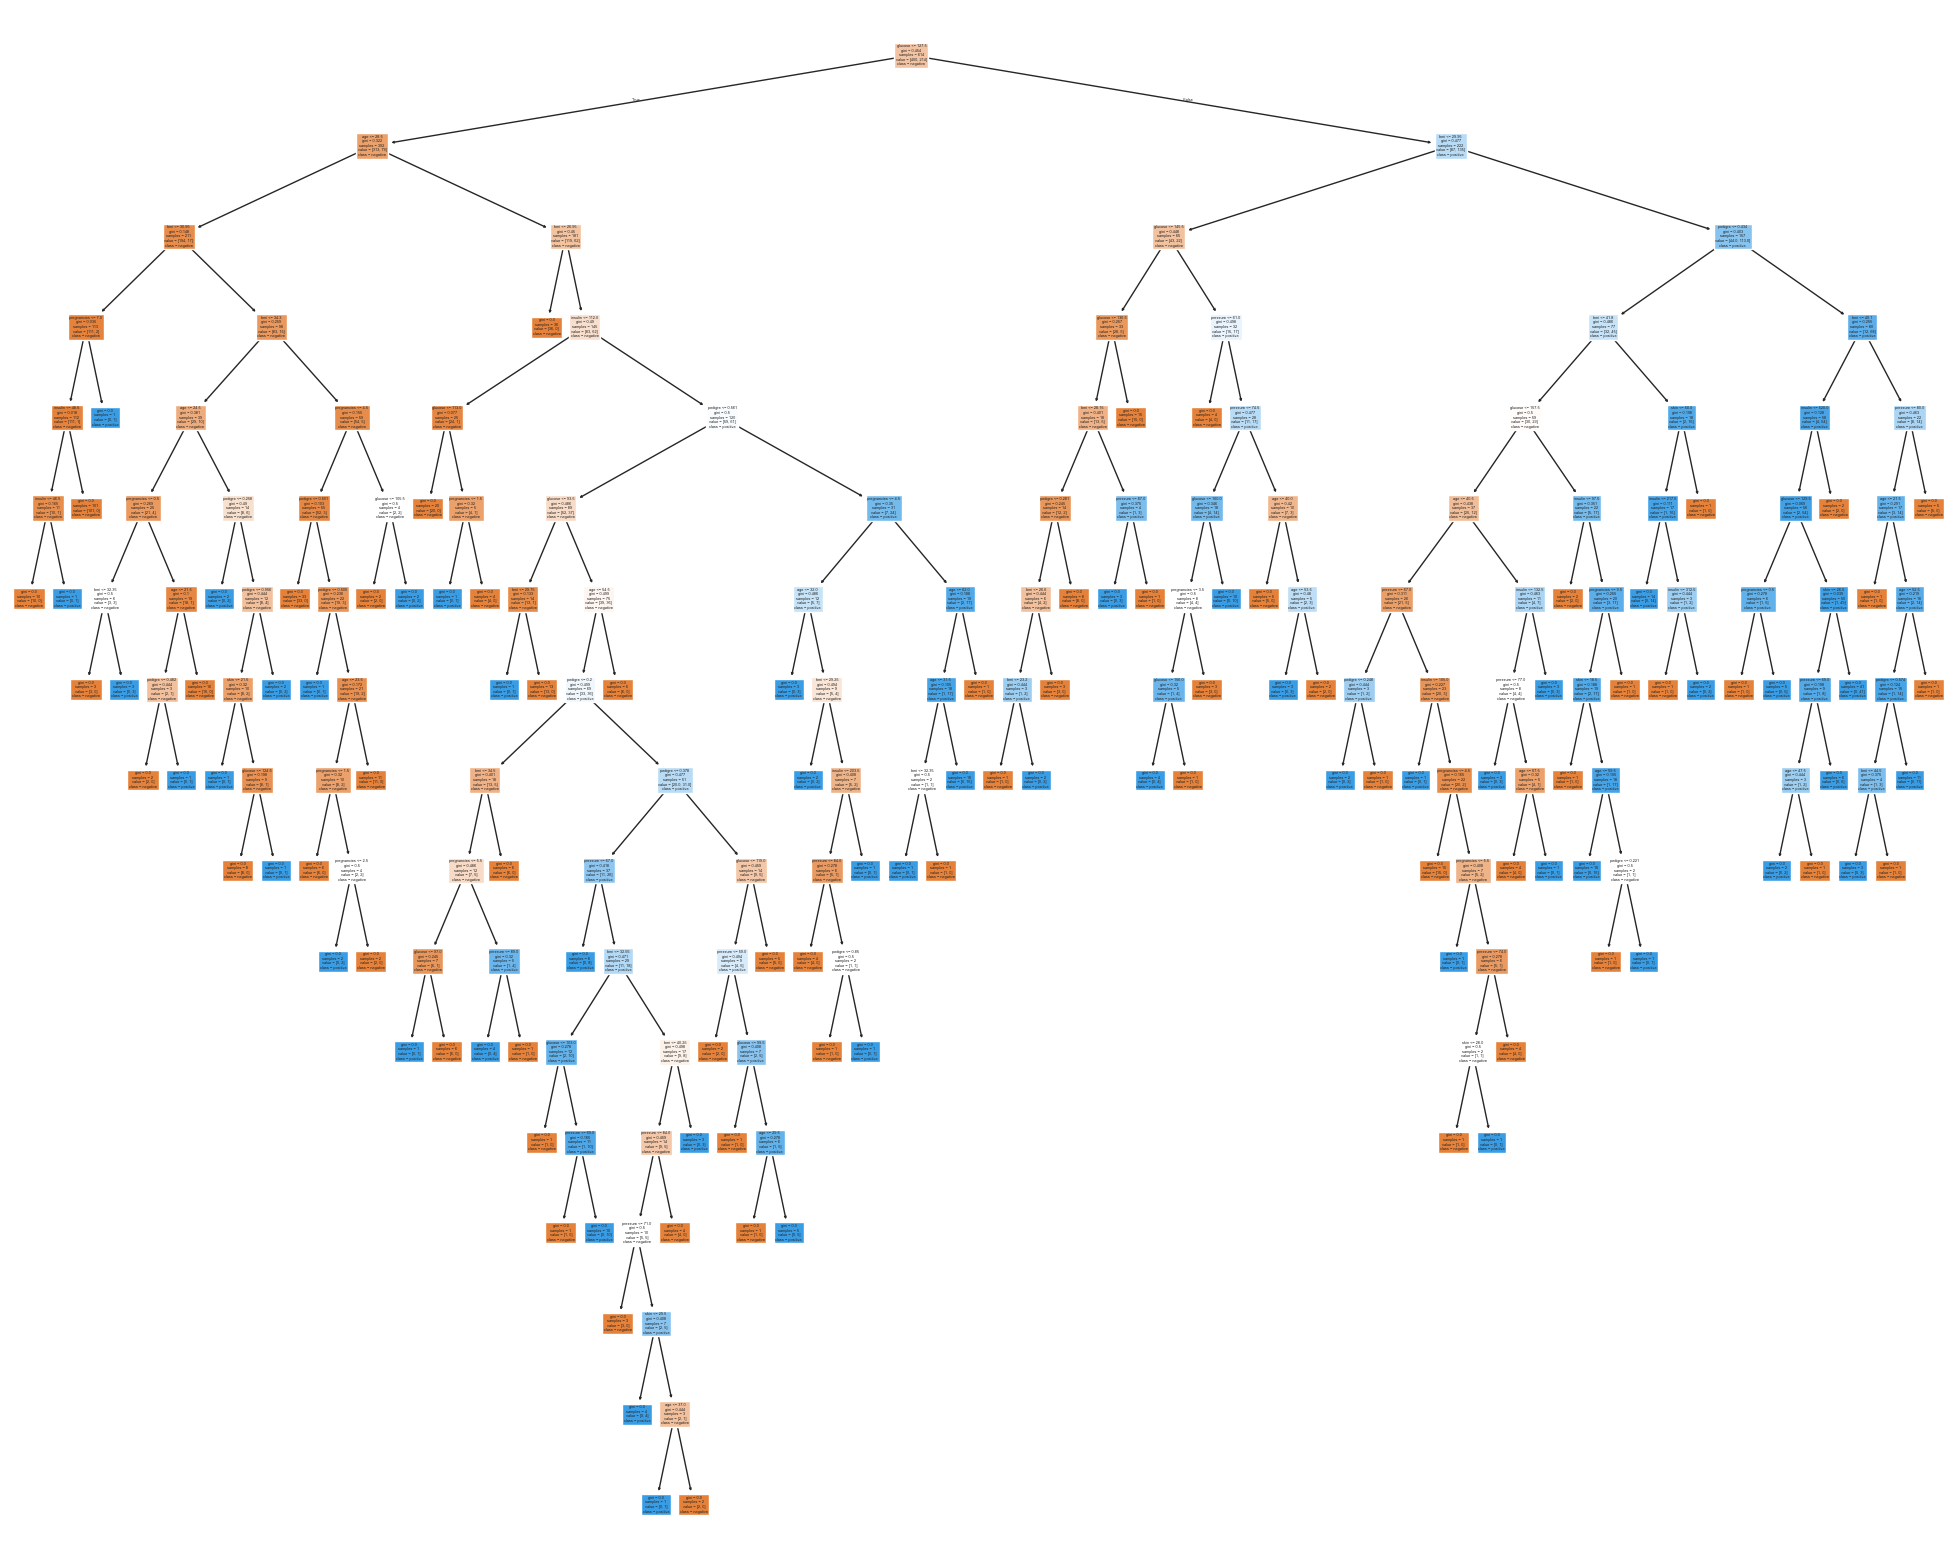

In [14]:
decision_tree_default =  DecisionTreeClassifier(random_state = 0)
decision_tree_default = decision_tree_default.fit(x_train, y_train)

fig = plt.figure(figsize=(25,20))
plot_tree(decision_tree_default, feature_names = x_train.columns, class_names = ['negative', 'positive'], filled=True)
plt.show()

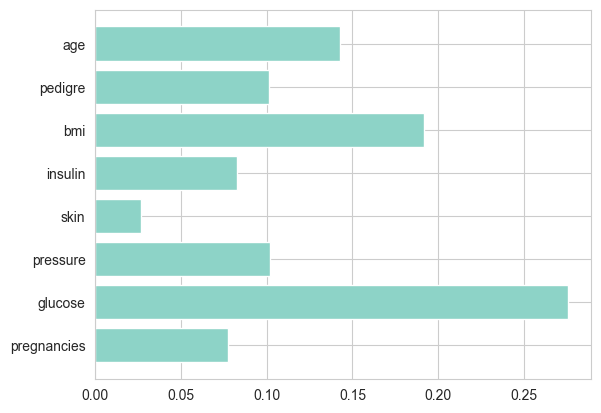

In [15]:
plt.barh(decision_tree_default.feature_names_in_, decision_tree_default.feature_importances_)
plt.show()

All variables are considered for this tree.

#### **FIRST MODEL** - DEFAULT PARAMS - PREDICT

In [16]:
y_default_model_predict = decision_tree_default.predict(x_test)

print("Confusion Matrix")
print("Rows are actual and columns are predicted")
print(f"{confusion_matrix(y_test, y_default_model_predict)}\n")

Confusion Matrix
Rows are actual and columns are predicted
[[77 23]
 [24 30]]



In [17]:
print("""
    Precision - When the model predicts this class, how often is it correct?,
    Recall - Out of all real cases of this class, how many did we catch?
    F1 score - Balance between precision and recall, higher the better
    Support - How many real samples of this class exist?
""")
print(classification_report(y_test, y_default_model_predict))


    Precision - When the model predicts this class, how often is it correct?,
    Recall - Out of all real cases of this class, how many did we catch?
    F1 score - Balance between precision and recall, higher the better
    Support - How many real samples of this class exist?

              precision    recall  f1-score   support

           0       0.76      0.77      0.77       100
           1       0.57      0.56      0.56        54

    accuracy                           0.69       154
   macro avg       0.66      0.66      0.66       154
weighted avg       0.69      0.69      0.69       154



Accuracy is **0.69** and should be improved.

### **SECOND MODEL** - RANDOM PARAMS

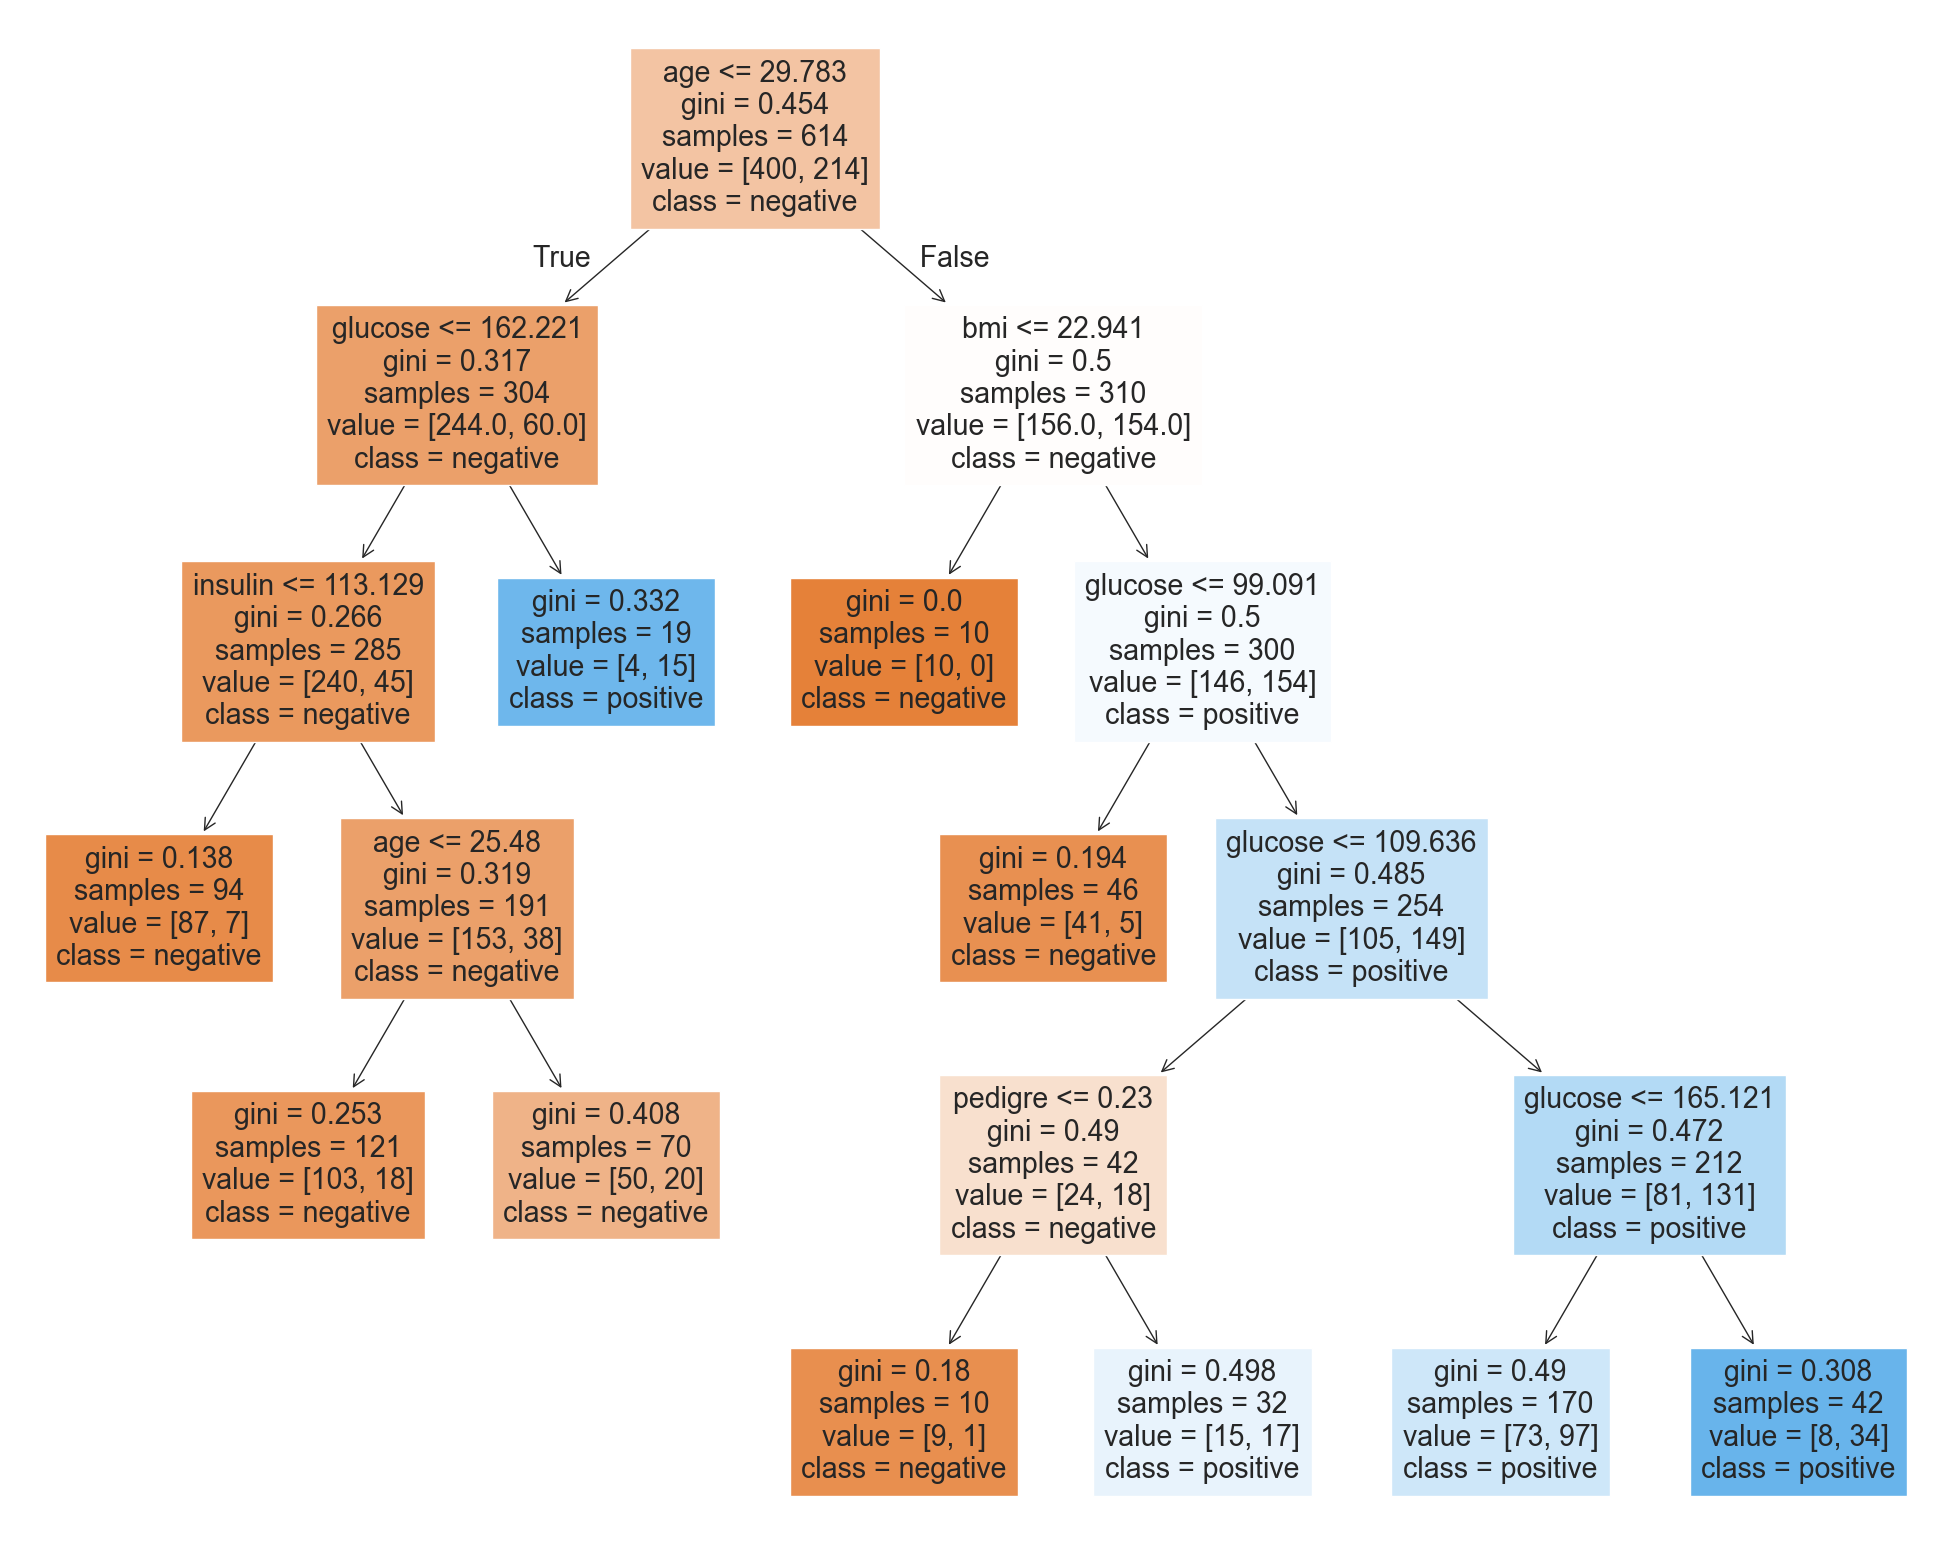

In [18]:
decision_tree_rand =  DecisionTreeClassifier(random_state = 0, criterion = "gini", splitter = 'random', max_leaf_nodes=10, min_samples_leaf = 5, max_depth= 5)
decision_tree_rand = decision_tree_rand.fit(x_train, y_train)

fig = plt.figure(figsize=(25,20))
plot_tree(decision_tree_rand, feature_names = x_train.columns, class_names = ['negative', 'positive'], filled=True)
plt.show()

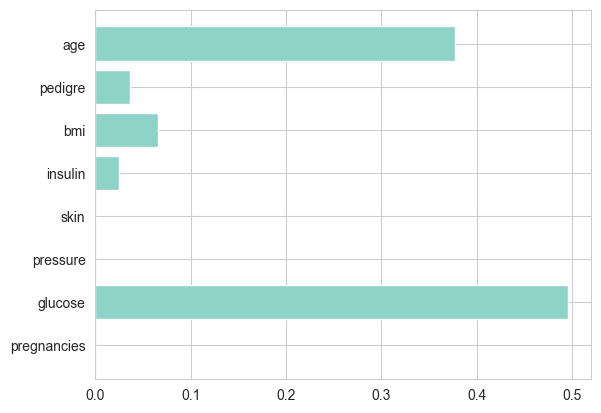

In [19]:
plt.barh(decision_tree_rand.feature_names_in_, decision_tree_rand.feature_importances_)
plt.show()

*Skin*, *pressure* and *pregnancies* are not considered for this tree.

#### **SECOND MODEL** - RANDOM PARAMS - PREDICT

In [20]:
y_first_model_predict = decision_tree_rand.predict(x_test)

print("Confusion Matrix")
print("Rows are actual and columns are predicted")
print(f"{confusion_matrix(y_test, y_first_model_predict)}\n")

Confusion Matrix
Rows are actual and columns are predicted
[[83 17]
 [20 34]]



In [21]:
print("""
    Precision - When the model predicts this class, how often is it correct?,
    Recall - Out of all real cases of this class, how many did we catch?
    F1 score - Balance between precision and recall, higher the better
    Support - How many real samples of this class exist?
""")
print(classification_report(y_test, y_first_model_predict))


    Precision - When the model predicts this class, how often is it correct?,
    Recall - Out of all real cases of this class, how many did we catch?
    F1 score - Balance between precision and recall, higher the better
    Support - How many real samples of this class exist?

              precision    recall  f1-score   support

           0       0.81      0.83      0.82       100
           1       0.67      0.63      0.65        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



Accuracy is **0.76**, that is significant improvement considering **0.69** for default params.

### **THIRD MODEL** - RANDOM PARAMS, REDUCED FEATURES

We can remove unused features to see if there will be any improvement to the model.

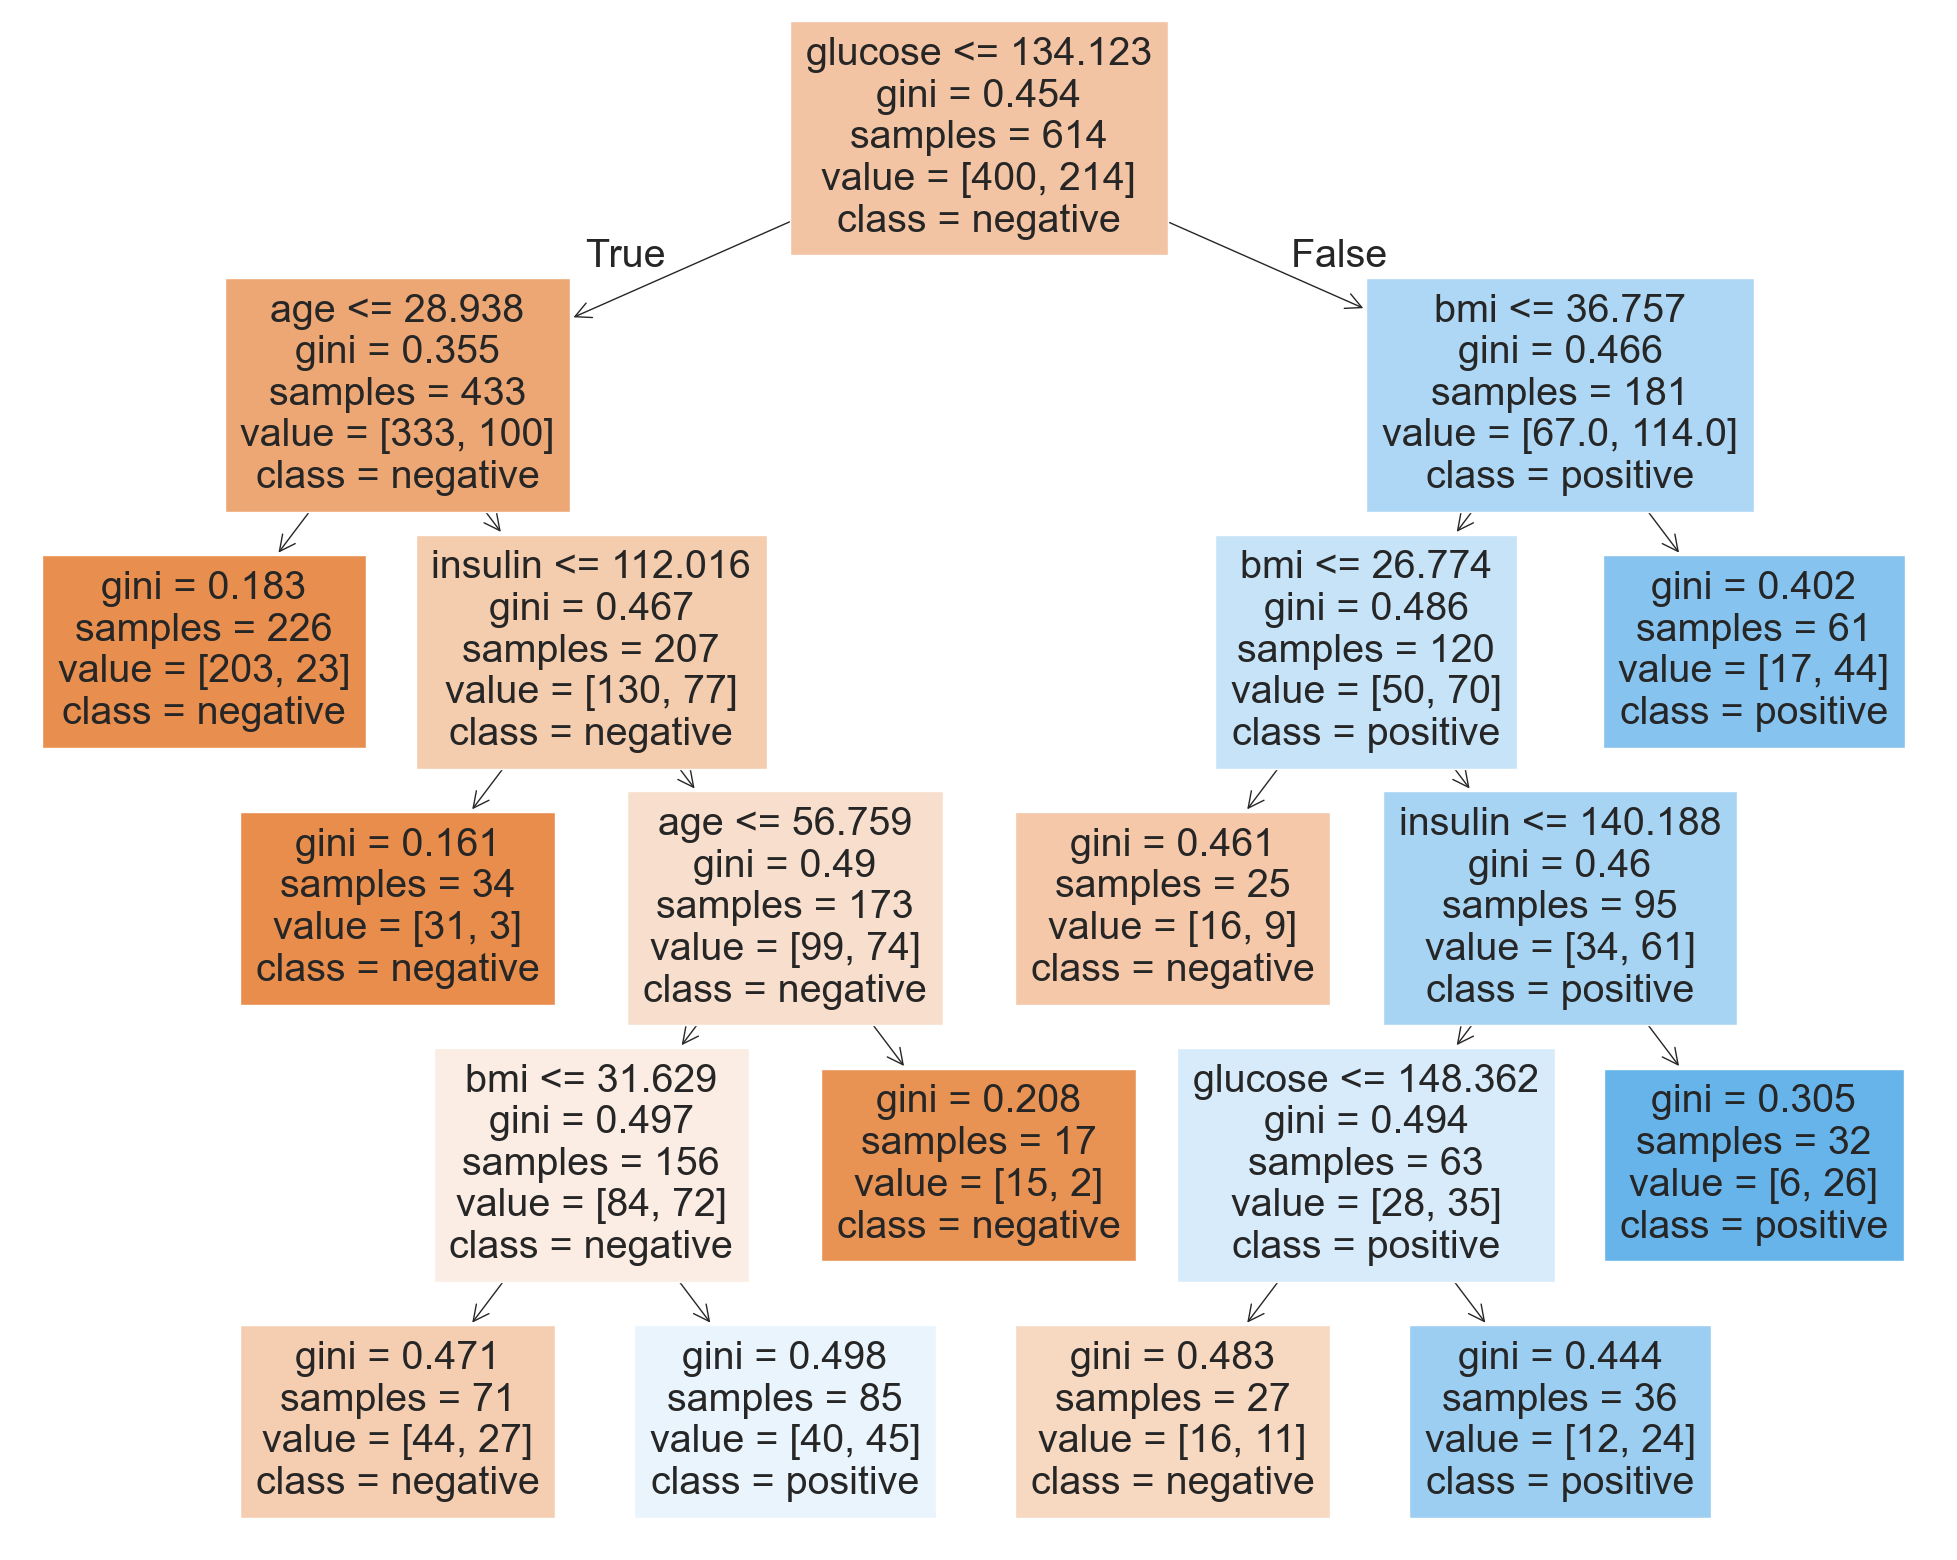

In [22]:
x_train_reduced = x_train.drop(columns=["skin", "pressure", "pregnancies"])

decision_tree_reduced =  DecisionTreeClassifier(random_state = 0, criterion = "gini", splitter = 'random', max_leaf_nodes=10, min_samples_leaf = 5, max_depth= 5)
decision_tree_reduced = decision_tree_reduced.fit(x_train_reduced, y_train)

fig = plt.figure(figsize=(25,20))
plot_tree(decision_tree_reduced, feature_names = x_train_reduced.columns, class_names = ['negative', 'positive'], filled=True)
plt.show()

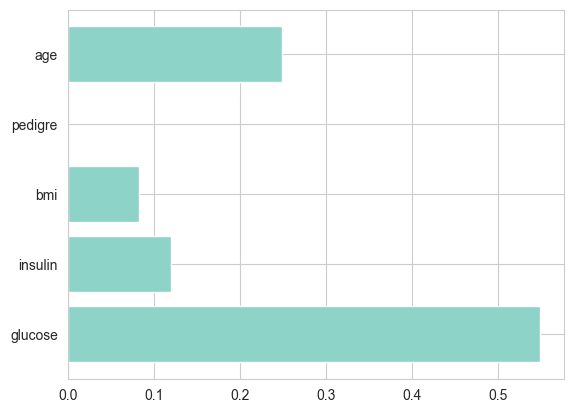

In [23]:
plt.barh(decision_tree_reduced.feature_names_in_, decision_tree_reduced.feature_importances_)
plt.show()

Now we see that *pedigree* is not considered.

#### **THIRD MODEL** - RANDOM PARAMS, REDUCED FEATURES - PREDICT

In [24]:
x_test_reduced = x_test.drop(columns=["skin", "pressure", "pregnancies"])
y_third_model_predict = decision_tree_reduced.predict(x_test_reduced)

print("Confusion Matrix")
print("Rows are actual and columns are predicted")
print(f"{confusion_matrix(y_test, y_third_model_predict)}\n")

Confusion Matrix
Rows are actual and columns are predicted
[[82 18]
 [17 37]]



In [25]:
print("""
    Precision - When the model predicts this class, how often is it correct?,
    Recall - Out of all real cases of this class, how many did we catch?
    F1 score - Balance between precision and recall, higher the better
    Support - How many real samples of this class exist?
""")
print(classification_report(y_test, y_third_model_predict))


    Precision - When the model predicts this class, how often is it correct?,
    Recall - Out of all real cases of this class, how many did we catch?
    F1 score - Balance between precision and recall, higher the better
    Support - How many real samples of this class exist?

              precision    recall  f1-score   support

           0       0.83      0.82      0.82       100
           1       0.67      0.69      0.68        54

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



Accuracy is **0.77**, that is a bit of improvement **0.76** from random params.

### **FOURTH MODEL** - RANDOM PARAMS, MORE REDUCED FEATURES

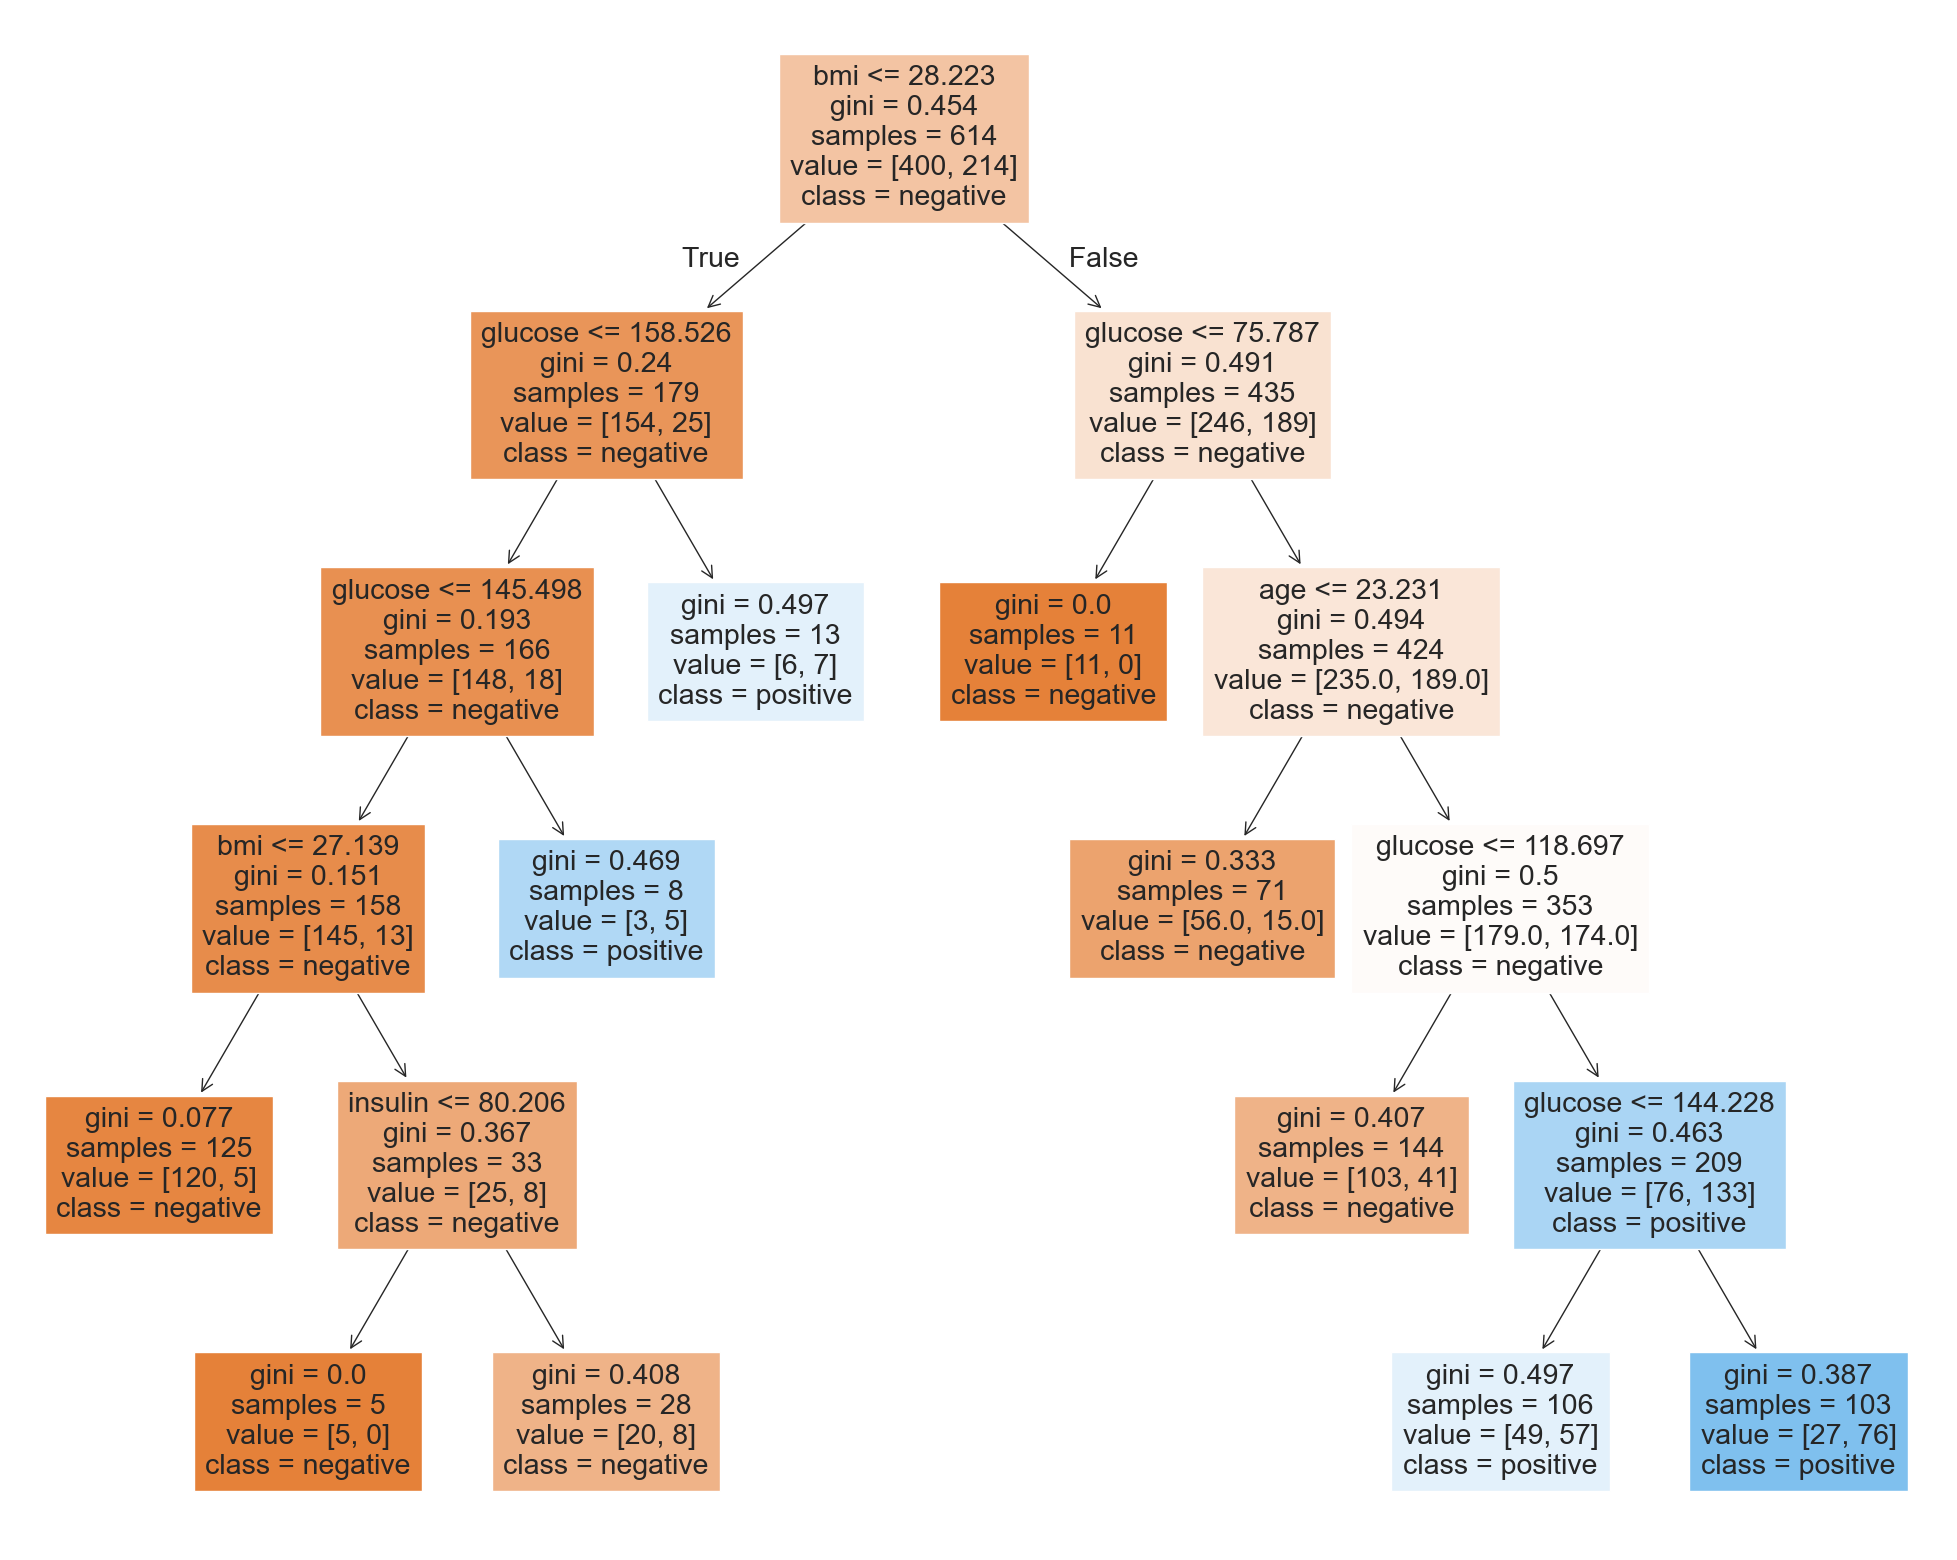

In [26]:
x_train_reduced_max = x_train_reduced.drop(columns=["pedigre"])

decision_tree_reduced_max =  DecisionTreeClassifier(random_state = 0, criterion = "gini", splitter = 'random', max_leaf_nodes=10, min_samples_leaf = 5, max_depth= 5)
decision_tree_reduced_max = decision_tree_reduced_max.fit(x_train_reduced_max, y_train)

fig = plt.figure(figsize=(25,20))
plot_tree(decision_tree_reduced_max, feature_names = x_train_reduced_max.columns, class_names = ['negative', 'positive'], filled=True)
plt.show()

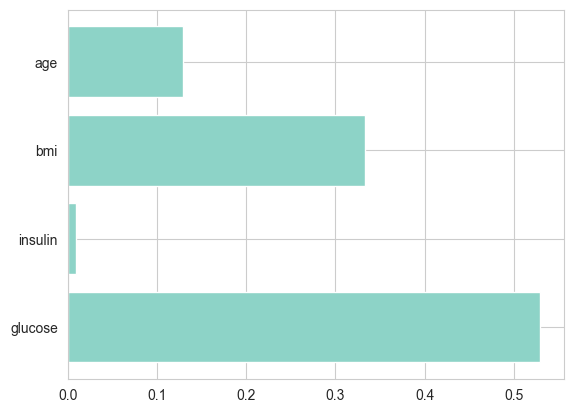

In [27]:
plt.barh(decision_tree_reduced_max.feature_names_in_, decision_tree_reduced_max.feature_importances_)
plt.show()

#### **FOURTH MODEL** - RANDOM PARAMS, MORE REDUCED FEATURES - PREDICT

In [28]:
x_test_reduced_max = x_test_reduced.drop(columns=["pedigre"])
y_fourth_model_predict = decision_tree_reduced_max.predict(x_test_reduced_max)

print("Confusion Matrix")
print("Rows are actual and columns are predicted")
print(f"{confusion_matrix(y_test, y_fourth_model_predict)}\n")

Confusion Matrix
Rows are actual and columns are predicted
[[85 15]
 [19 35]]



In [29]:
print("""
    Precision - When the model predicts this class, how often is it correct?,
    Recall - Out of all real cases of this class, how many did we catch?
    F1 score - Balance between precision and recall, higher the better
    Support - How many real samples of this class exist?
""")
print(classification_report(y_test, y_fourth_model_predict))


    Precision - When the model predicts this class, how often is it correct?,
    Recall - Out of all real cases of this class, how many did we catch?
    F1 score - Balance between precision and recall, higher the better
    Support - How many real samples of this class exist?

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       100
           1       0.70      0.65      0.67        54

    accuracy                           0.78       154
   macro avg       0.76      0.75      0.75       154
weighted avg       0.78      0.78      0.78       154



Accuracy is **0.78**, that is a bit of improvement **0.77** from random reduced params. But, recall tells us it misses more positives than previous model.


### **FIFTH MODEL** - RANDOM PARAMS, MORE REDUCED FEATURES, LESS DEPTH

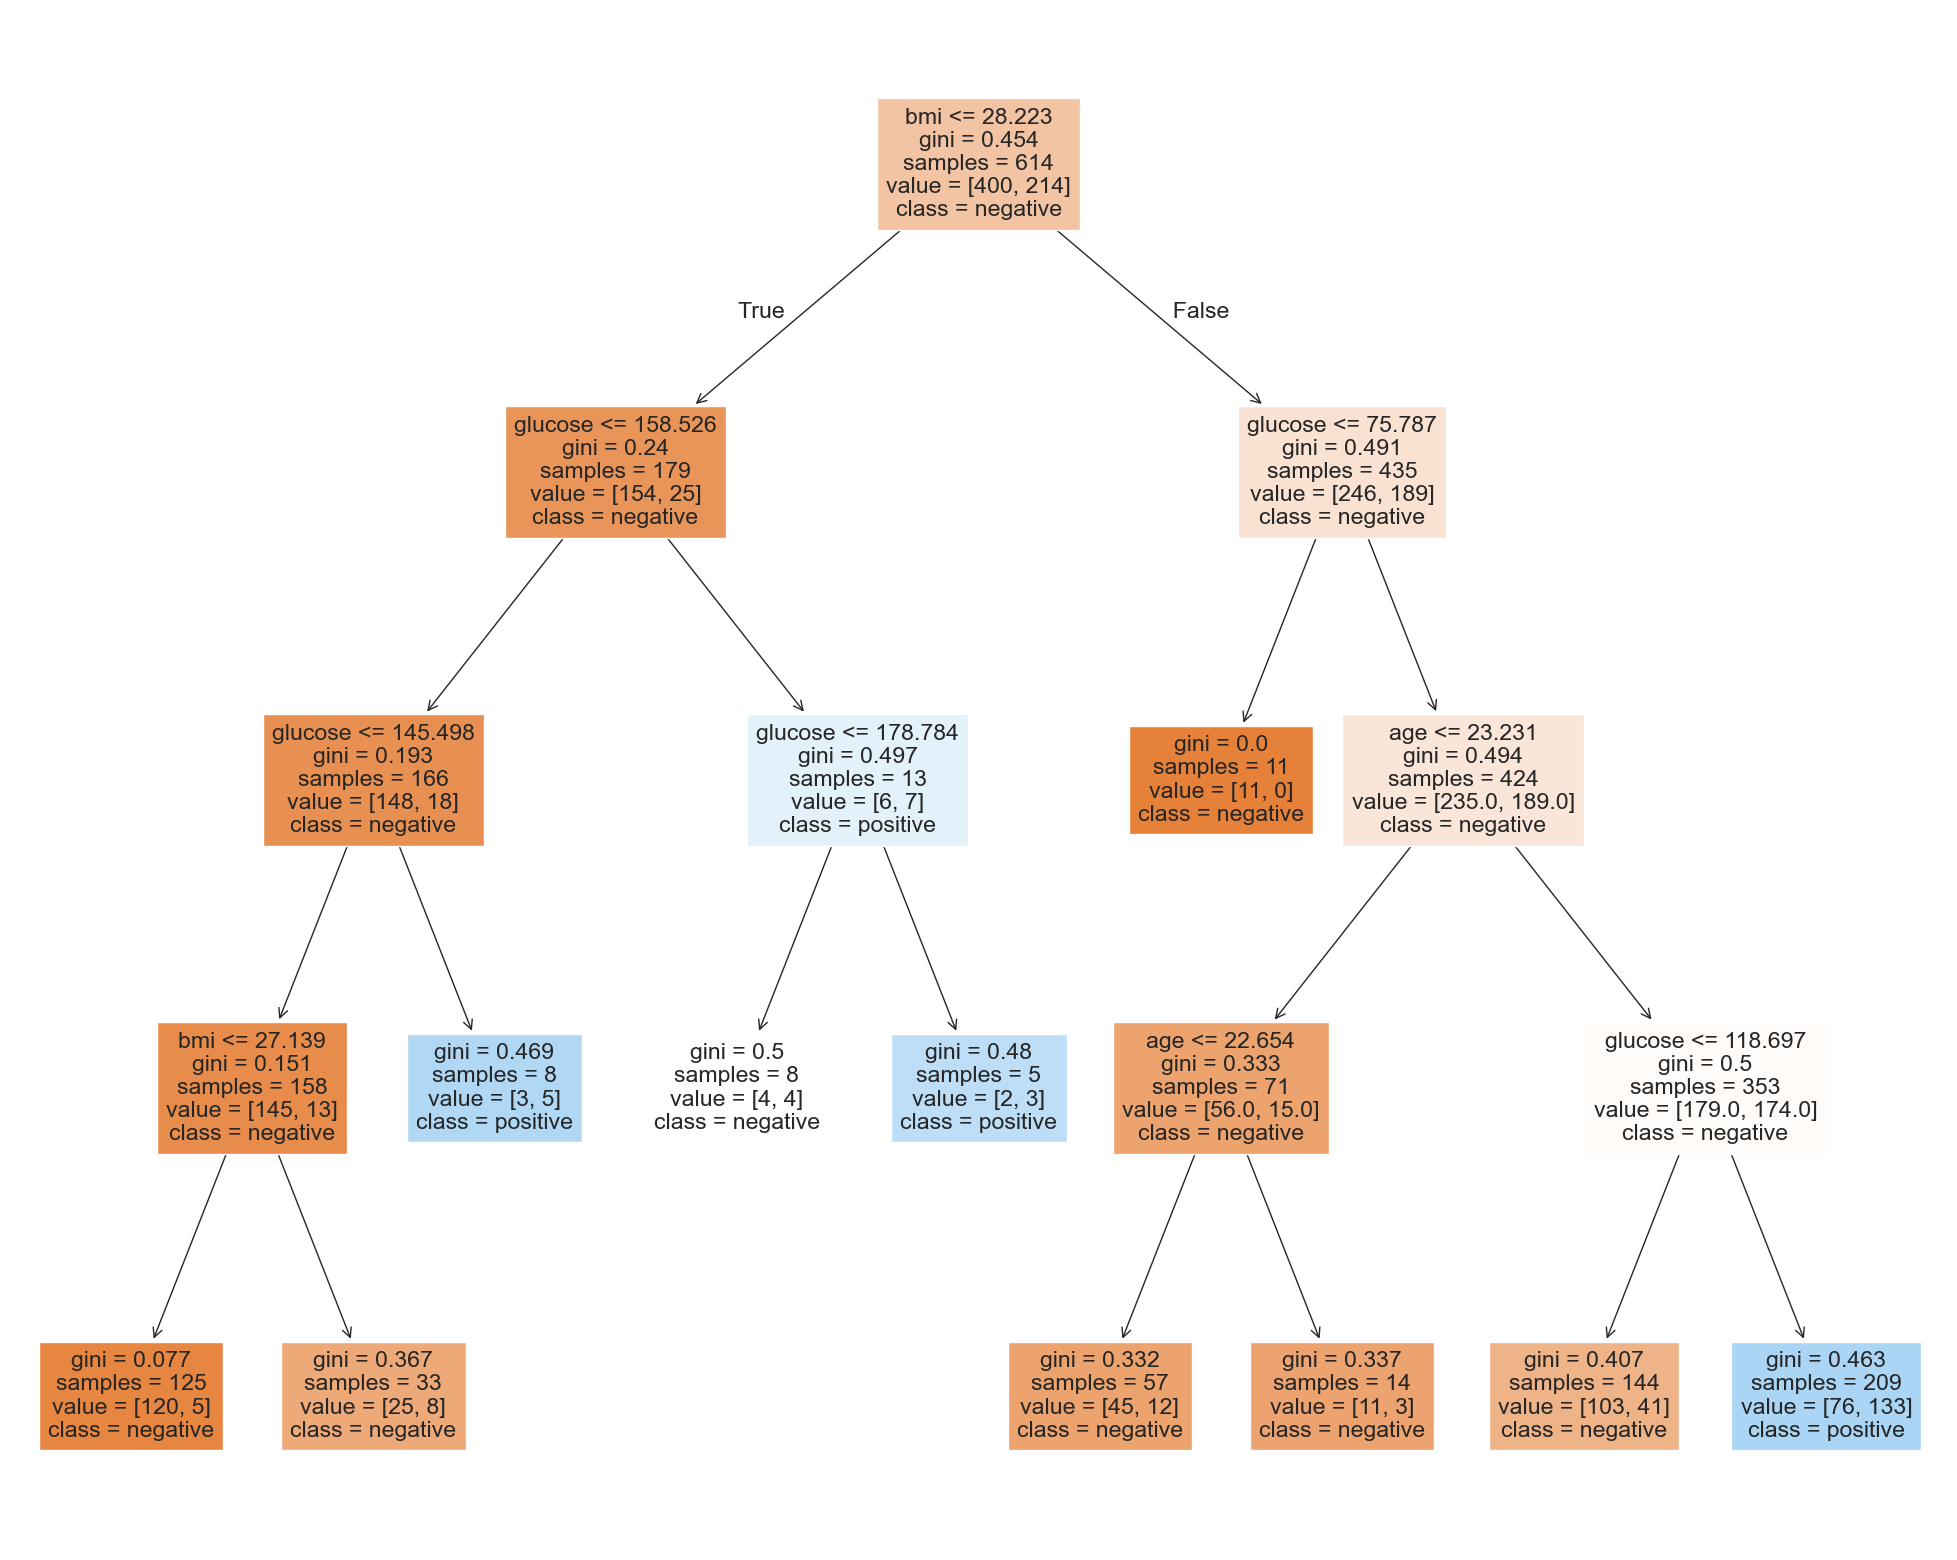

In [30]:
decision_tree_reduced_max_less =  DecisionTreeClassifier(random_state = 0, criterion = "gini", splitter = 'random', max_leaf_nodes=10, min_samples_leaf = 5, max_depth= 4)
decision_tree_reduced_max_less = decision_tree_reduced_max_less.fit(x_train_reduced_max, y_train)

fig = plt.figure(figsize=(25,20))
plot_tree(decision_tree_reduced_max_less, feature_names = x_train_reduced_max.columns, class_names = ['negative', 'positive'], filled=True)
plt.show()

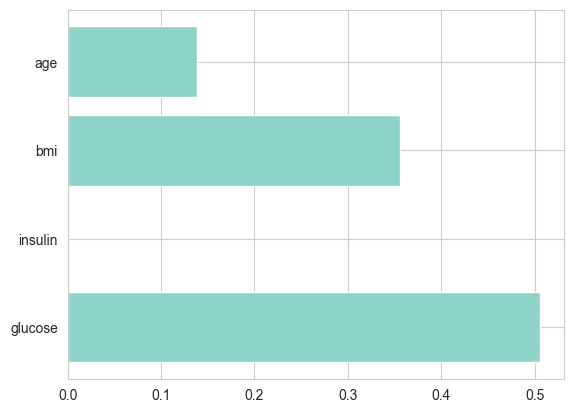

In [31]:
plt.barh(decision_tree_reduced_max_less.feature_names_in_, decision_tree_reduced_max_less.feature_importances_)
plt.show()

#### **FIFTH MODEL** - RANDOM PARAMS, MORE REDUCED FEATURES, LESS DEPTH - PREDICT

In [32]:
y_fifth_model_predict = decision_tree_reduced_max_less.predict(x_test_reduced_max)

print("Confusion Matrix")
print("Rows are actual and columns are predicted")
print(f"{confusion_matrix(y_test, y_fifth_model_predict)}\n")

Confusion Matrix
Rows are actual and columns are predicted
[[86 14]
 [19 35]]



In [33]:
print("""
    Precision - When the model predicts this class, how often is it correct?,
    Recall - Out of all real cases of this class, how many did we catch?
    F1 score - Balance between precision and recall, higher the better
    Support - How many real samples of this class exist?
""")
print(classification_report(y_test, y_fifth_model_predict))


    Precision - When the model predicts this class, how often is it correct?,
    Recall - Out of all real cases of this class, how many did we catch?
    F1 score - Balance between precision and recall, higher the better
    Support - How many real samples of this class exist?

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       100
           1       0.71      0.65      0.68        54

    accuracy                           0.79       154
   macro avg       0.77      0.75      0.76       154
weighted avg       0.78      0.79      0.78       154



Model is now simpler with a small improvement in accuracy - **0.79**.